# Variante 2: Multiprocessing Static
Bilder werden aufgeteilt (np.array_split). Jeder Prozess bekommt seinen Chunk und arbeitet ihn sequenziell ab.

Hypothese: Static ist bei gleicher Auflösung (NIH) effizient, weil alle Chunks gleich lang dauern. Bei variabler Auflösung (Kaggle Pneumonia) kann ein Prozess zufällig viele große Bilder bekommen und zum Flaschenhals werden.

Technologie: multiprocessing.Process + numpy.array_split

#### Imports

In [1]:
import sys
import os
sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))

import multiprocessing
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import statistics
from pathlib import Path

from pipeline import process_image, get_image_paths

print(f"CPU-Kerne verfügbar: {multiprocessing.cpu_count()}")

CPU-Kerne verfügbar: 16


#### Konfiguration
Hinweis: Bitte an eigenes lokales Set-Up anpassen
(Laptop 1 = Maxim, Laptop 2 = Ella, Laptop 3 = Jordan)

In [2]:
LAPTOP_ID = 2

IMG_SIZE = (512, 512)
RUNS = 10

NIH_DIR            = "../data/nih_chest_xray"
KAGGLE_DIR         = "../data/kaggle_pneumonia"

RESULTS_DIR        = f"results/laptop{LAPTOP_ID}"
RESULTS_CSV        = f"{RESULTS_DIR}/results_static_laptop{LAPTOP_ID}.csv"

IMAGE_COUNTS   = [100, 500, 1000, 5000]
PROCESS_COUNTS = [1, 2, 4, 8]

Path(RESULTS_DIR).mkdir(parents=True, exist_ok=True)

#### 1. Get Images

In [3]:
nih_paths    = get_image_paths(NIH_DIR)
kaggle_paths = get_image_paths(KAGGLE_DIR)

print(f"NIH Bilder gefunden:             {len(nih_paths)}")
print(f"Kaggle Pneumonia Bilder gefunden: {len(kaggle_paths)}")

NIH Bilder gefunden:             10000
Kaggle Pneumonia Bilder gefunden: 5216


#### 2. Process Image

In [4]:
def worker_static(chunk, return_list):
    local = [process_image(path) for path in chunk]
    return_list.extend(local)


def run_static(image_paths, n_processes):
    chunks = [list(c) for c in np.array_split(image_paths, n_processes) if len(c) > 0]

    manager     = multiprocessing.Manager()
    return_list = manager.list()

    processes = [
        multiprocessing.Process(target=worker_static, args=(chunk, return_list))
        for chunk in chunks
    ]

    t_start = time.perf_counter()
    for p in processes: p.start()
    for p in processes: p.join()
    total_time = time.perf_counter() - t_start

    return total_time, list(return_list)

#### 3. Run

In [5]:
def benchmark():
    rows = []

    datasets = [
        ("NIH",              nih_paths),
        ("Kaggle Pneumonia", kaggle_paths),
    ]

    for dataset_name, all_paths in datasets:
        print(f"\n=== {dataset_name} ===")

        for n_img in IMAGE_COUNTS:
            subset = all_paths[:n_img]
            if len(subset) < n_img:
                print(f"  Nur {len(subset)} Bilder verfügbar (angefragt: {n_img})")
                continue

            for n_proc in PROCESS_COUNTS:
                runtimes = []
                for run in range(RUNS):
                    runtime, _ = run_static(subset, n_proc)
                    runtimes.append(runtime)

                median_runtime   = statistics.median(runtimes)
                median_throughput = n_img / median_runtime

                rows.append({
                    "Laptop":        LAPTOP_ID,
                    "Variante":      "Static",
                    "Datensatz":     dataset_name,
                    "Bilder":        n_img,
                    "Prozesse":      n_proc,
                    "Laufzeit in s": round(median_runtime, 3),
                    "Speedup":       None,
                    "Efficiency":    None,
                    "Throughput":    round(median_throughput, 2),
                })
                print(f"  {n_img} Bilder | {n_proc} Prozesse | Median: {median_runtime:.3f}s")

    return pd.DataFrame(rows)

df = benchmark()
df


=== NIH ===
  100 Bilder | 1 Prozesse | Median: 0.740s
  100 Bilder | 2 Prozesse | Median: 0.419s
  100 Bilder | 4 Prozesse | Median: 0.280s
  100 Bilder | 8 Prozesse | Median: 0.231s
  500 Bilder | 1 Prozesse | Median: 3.579s
  500 Bilder | 2 Prozesse | Median: 2.025s
  500 Bilder | 4 Prozesse | Median: 1.255s
  500 Bilder | 8 Prozesse | Median: 0.874s
  1000 Bilder | 1 Prozesse | Median: 7.126s
  1000 Bilder | 2 Prozesse | Median: 4.001s
  1000 Bilder | 4 Prozesse | Median: 2.451s
  1000 Bilder | 8 Prozesse | Median: 1.694s
  5000 Bilder | 1 Prozesse | Median: 35.641s
  5000 Bilder | 2 Prozesse | Median: 19.922s
  5000 Bilder | 4 Prozesse | Median: 11.911s
  5000 Bilder | 8 Prozesse | Median: 8.284s

=== Kaggle Pneumonia ===
  100 Bilder | 1 Prozesse | Median: 0.989s
  100 Bilder | 2 Prozesse | Median: 0.576s
  100 Bilder | 4 Prozesse | Median: 0.386s
  100 Bilder | 8 Prozesse | Median: 0.312s
  500 Bilder | 1 Prozesse | Median: 4.902s
  500 Bilder | 2 Prozesse | Median: 2.838s
  50

,Laptop,Variante,Datensatz,Bilder,Prozesse,Laufzeit in s,Speedup,Efficiency,Throughput
0,2,Static,NIH,100,1,0.740,None,None,135.18
1,2,Static,NIH,100,2,0.419,None,None,238.91
2,2,Static,NIH,100,4,0.280,None,None,357.46
3,2,Static,NIH,100,8,0.231,None,None,432.47
4,2,Static,NIH,500,1,3.579,None,None,139.68
5,2,Static,NIH,500,2,2.025,None,None,246.95
6,2,Static,NIH,500,4,1.255,None,None,398.52
7,2,Static,NIH,500,8,0.874,None,None,571.90
8,2,Static,NIH,1000,1,7.126,None,None,140.34
9,2,Static,NIH,1000,2,4.001,None,None,249.92


#### 4. Speedup und Efficiency

In [6]:
baseline = (
    df[df["Prozesse"] == 1]
    .set_index(["Datensatz", "Bilder"])["Laufzeit in s"]
)

df["Speedup"]   = df.apply(lambda r: round(baseline.get((r["Datensatz"], r["Bilder"]), float("nan")) / r["Laufzeit in s"], 3), axis=1)
df["Efficiency"] = df.apply(lambda r: round(r["Speedup"] / r["Prozesse"], 3), axis=1)

df.to_csv(RESULTS_CSV, index=False)
print(f"Gespeichert: {RESULTS_CSV}")
df

Gespeichert: results/laptop2/results_static_laptop2.csv


,Laptop,Variante,Datensatz,Bilder,Prozesse,Laufzeit in s,Speedup,Efficiency,Throughput
0,2,Static,NIH,100,1,0.740,1.000,1.000,135.18
1,2,Static,NIH,100,2,0.419,1.766,0.883,238.91
2,2,Static,NIH,100,4,0.280,2.643,0.661,357.46
3,2,Static,NIH,100,8,0.231,3.203,0.400,432.47
4,2,Static,NIH,500,1,3.579,1.000,1.000,139.68
5,2,Static,NIH,500,2,2.025,1.767,0.883,246.95
6,2,Static,NIH,500,4,1.255,2.852,0.713,398.52
7,2,Static,NIH,500,8,0.874,4.095,0.512,571.90
8,2,Static,NIH,1000,1,7.126,1.000,1.000,140.34
9,2,Static,NIH,1000,2,4.001,1.781,0.890,249.92


#### 5. Plots

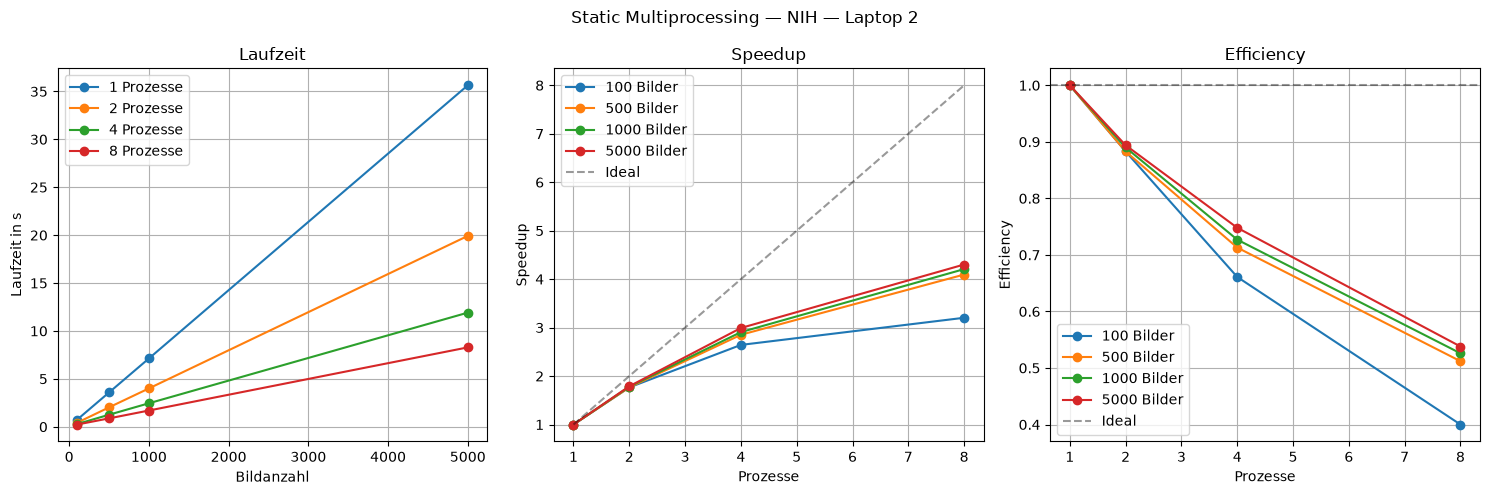

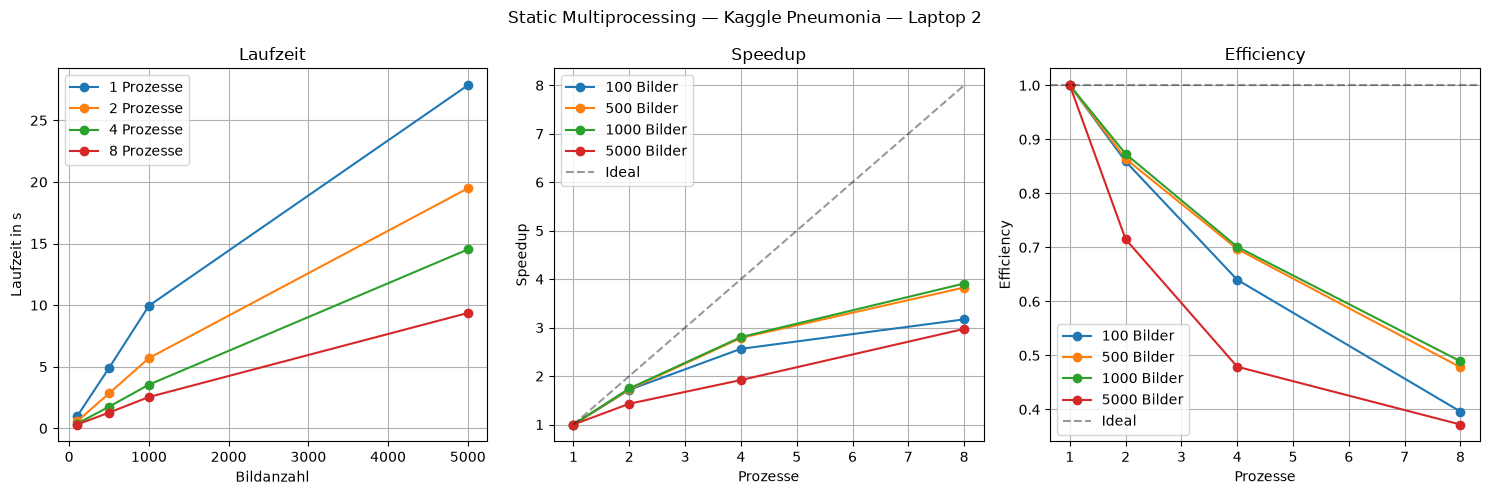

In [7]:
Path("plots").mkdir(exist_ok=True)

for dataset_name in ["NIH", "Kaggle Pneumonia"]:
    sub_ds = df[df["Datensatz"] == dataset_name]

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(f"Static Multiprocessing — {dataset_name} — Laptop {LAPTOP_ID}")

    ax = axes[0]
    for n_proc in PROCESS_COUNTS:
        sub = sub_ds[sub_ds["Prozesse"] == n_proc]
        ax.plot(sub["Bilder"], sub["Laufzeit in s"], marker="o", label=f"{n_proc} Prozesse")
    ax.set_xlabel("Bildanzahl")
    ax.set_ylabel("Laufzeit in s")
    ax.set_title("Laufzeit")
    ax.legend()
    ax.grid(True)

    ax = axes[1]
    for n_img in IMAGE_COUNTS:
        sub = sub_ds[sub_ds["Bilder"] == n_img]
        if not sub.empty:
            ax.plot(sub["Prozesse"], sub["Speedup"], marker="o", label=f"{n_img} Bilder")
    ax.plot(PROCESS_COUNTS, PROCESS_COUNTS, "k--", alpha=0.4, label="Ideal")
    ax.set_xlabel("Prozesse")
    ax.set_ylabel("Speedup")
    ax.set_title("Speedup")
    ax.legend()
    ax.grid(True)

    ax = axes[2]
    for n_img in IMAGE_COUNTS:
        sub = sub_ds[sub_ds["Bilder"] == n_img]
        if not sub.empty:
            ax.plot(sub["Prozesse"], sub["Efficiency"], marker="o", label=f"{n_img} Bilder")
    ax.axhline(1.0, color="k", linestyle="--", alpha=0.4, label="Ideal")
    ax.set_xlabel("Prozesse")
    ax.set_ylabel("Efficiency")
    ax.set_title("Efficiency")
    ax.legend()
    ax.grid(True)

    plt.tight_layout()
    fname = f"{RESULTS_DIR}/static_{dataset_name.lower().replace(' ', '_')}_laptop{LAPTOP_ID}.png"
    plt.savefig(fname, dpi=150)
    plt.show()